Electricity Consumption Analysis Using Python

Objective:
To analyze electricity consumption data and identify patterns in energy usage, including daily consumption and peak usage periods.

Tools Used:
Python, Pandas, NumPy, Matplotlib, and Google Colab.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = {
    "Day": ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday",
            "Saturday", "Sunday"],
    "Energy_Consumption_kWh": [42, 45, 48, 50, 55, 63, 58],
    "Peak_Consumption_kWh": [18, 20, 21, 23, 27, 32, 29],
    "Off_Peak_Consumption_kWh": [24, 25, 27, 27, 28, 31, 29]
}

df = pd.DataFrame(data)

df

,Day,Energy_Consumption_kWh,Peak_Consumption_kWh,Off_Peak_Consumption_kWh
0,Monday,42,18,24
1,Tuesday,45,20,25
2,Wednesday,48,21,27
3,Thursday,50,23,27
4,Friday,55,27,28
5,Saturday,63,32,31
6,Sunday,58,29,29


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Day                       7 non-null      object
 1   Energy_Consumption_kWh    7 non-null      int64 
 2   Peak_Consumption_kWh      7 non-null      int64 
 3   Off_Peak_Consumption_kWh  7 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 356.0+ bytes


In [4]:
df.describe()

,Energy_Consumption_kWh,Peak_Consumption_kWh,Off_Peak_Consumption_kWh
count,7.000000,7.000000,7.000000
mean,51.571429,24.285714,27.285714
std,7.457818,5.154748,2.360387
min,42.000000,18.000000,24.000000
25%,46.500000,20.500000,26.000000
50%,50.000000,23.000000,27.000000
75%,56.500000,28.000000,28.500000
max,63.000000,32.000000,31.000000


Which day used the highest electricity?

In [5]:
highest_consumption = df.loc[df["Energy_Consumption_kWh"].idxmax()]

highest_consumption

,5
Day,Saturday
Energy_Consumption_kWh,63
Peak_Consumption_kWh,32
Off_Peak_Consumption_kWh,31


Which day used the least electricity?

In [7]:
lowest_consumption = df.loc[df["Energy_Consumption_kWh"].idxmin()]

lowest_consumption

,0
Day,Monday
Energy_Consumption_kWh,42
Peak_Consumption_kWh,18
Off_Peak_Consumption_kWh,24


Average energy consumption?

In [9]:
average_consumption = df["Energy_Consumption_kWh"].mean()

average_consumption

np.float64(51.57142857142857)

Comparison between peak and off-peak consumption?

In [10]:
total_peak = df["Peak_Consumption_kWh"].sum()
total_off_peak = df["Off_Peak_Consumption_kWh"].sum()

print("Total Peak Consumption:", total_peak, "kWh")
print("Total Off-Peak Consumption:", total_off_peak, "kWh")

Total Peak Consumption: 170 kWh
Total Off-Peak Consumption: 191 kWh


In [11]:
df["Peak_Percentage"] = (
    df["Peak_Consumption_kWh"] / df["Energy_Consumption_kWh"]
) * 100

df

,Day,Energy_Consumption_kWh,Peak_Consumption_kWh,Off_Peak_Consumption_kWh,Peak_Percentage
0,Monday,42,18,24,42.857143
1,Tuesday,45,20,25,44.444444
2,Wednesday,48,21,27,43.750000
3,Thursday,50,23,27,46.000000
4,Friday,55,27,28,49.090909
5,Saturday,63,32,31,50.793651
6,Sunday,58,29,29,50.000000


Which day had the highest percentage of its electricity consumption during peak hours?

In [12]:
highest_peak_day = df.loc[df["Peak_Percentage"].idxmax()]

highest_peak_day

,5
Day,Saturday
Energy_Consumption_kWh,63
Peak_Consumption_kWh,32
Off_Peak_Consumption_kWh,31
Peak_Percentage,50.793651


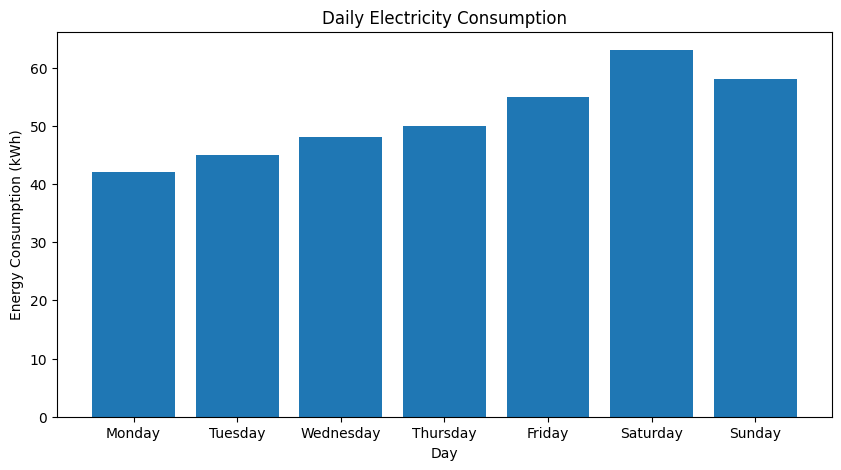

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(df["Day"], df["Energy_Consumption_kWh"])

plt.title("Daily Electricity Consumption")
plt.xlabel("Day")
plt.ylabel("Energy Consumption (kWh)")

plt.show()

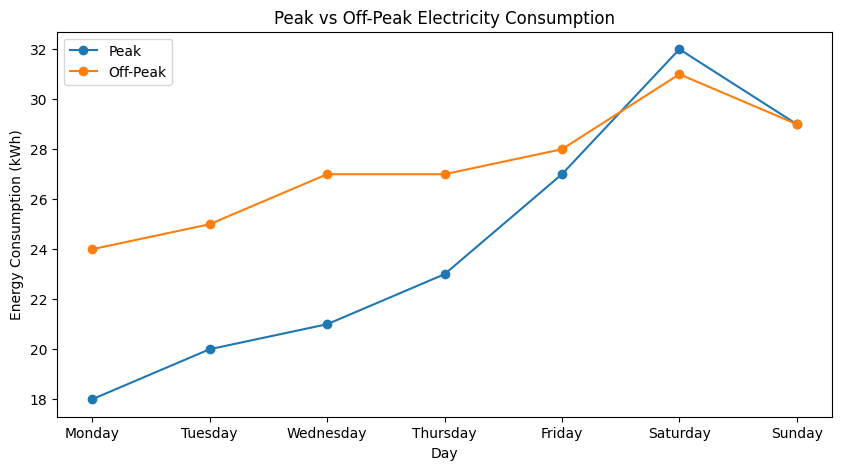

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(df["Day"], df["Peak_Consumption_kWh"], marker="o", label="Peak")
plt.plot(df["Day"], df["Off_Peak_Consumption_kWh"], marker="o", label="Off-Peak")

plt.title("Peak vs Off-Peak Electricity Consumption")
plt.xlabel("Day")
plt.ylabel("Energy Consumption (kWh)")

plt.legend()
plt.show()

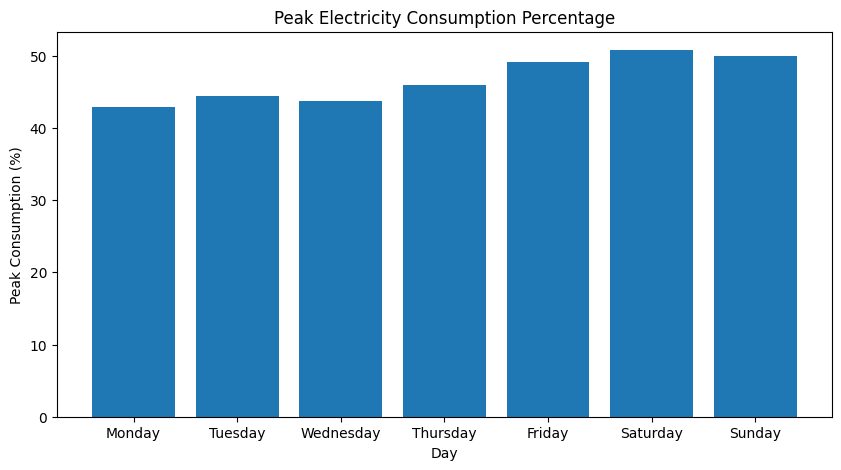

In [15]:
plt.figure(figsize=(10, 5))

plt.bar(df["Day"], df["Peak_Percentage"])

plt.title("Peak Electricity Consumption Percentage")
plt.xlabel("Day")
plt.ylabel("Peak Consumption (%)")

plt.show()

Calculate average peak percentage?

In [16]:
average_peak_percentage = df["Peak_Percentage"].mean()

average_peak_percentage

np.float64(46.70516388373532)

In [17]:
round(average_peak_percentage,2)

np.float64(46.71)

Average peak and off-peak consumption?

In [18]:
average_peak = df["Peak_Consumption_kWh"].mean()
average_off_peak = df["Off_Peak_Consumption_kWh"].mean()

print("Average Peak Consumption:", round(average_peak, 2), "kWh")
print("Average Off-Peak Consumption:", round(average_off_peak, 2), "kWh")

Average Peak Consumption: 24.29 kWh
Average Off-Peak Consumption: 27.29 kWh


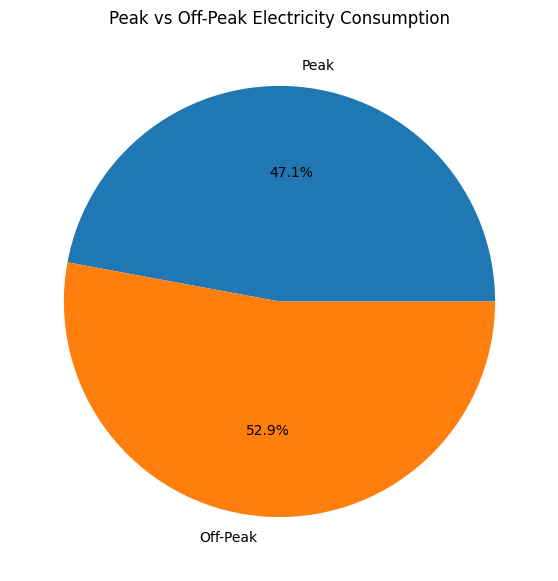

In [19]:
labels = ["Peak", "Off-Peak"]
values = [total_peak, total_off_peak]

plt.figure(figsize=(7, 7))

plt.pie(values, labels=labels, autopct="%1.1f%%")

plt.title("Peak vs Off-Peak Electricity Consumption")

plt.show()

In [21]:
df.isnull().sum()

,0
Day,0
Energy_Consumption_kWh,0
Peak_Consumption_kWh,0
Off_Peak_Consumption_kWh,0
Peak_Percentage,0


In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.sort_values("Energy_Consumption_kWh", ascending=False)

,Day,Energy_Consumption_kWh,Peak_Consumption_kWh,Off_Peak_Consumption_kWh,Peak_Percentage
5,Saturday,63,32,31,50.793651
6,Sunday,58,29,29,50.000000
4,Friday,55,27,28,49.090909
3,Thursday,50,23,27,46.000000
2,Wednesday,48,21,27,43.750000
1,Tuesday,45,20,25,44.444444
0,Monday,42,18,24,42.857143


In [24]:
high_consumption_days = df[
    df["Energy_Consumption_kWh"] > average_consumption
]

high_consumption_days

,Day,Energy_Consumption_kWh,Peak_Consumption_kWh,Off_Peak_Consumption_kWh,Peak_Percentage
4,Friday,55,27,28,49.090909
5,Saturday,63,32,31,50.793651
6,Sunday,58,29,29,50.000000


In [26]:
len(high_consumption_days)

3

Calculate the percentage of high-consumption days?

In [27]:
high_consumption_percentage = (len(high_consumption_days) / len(df)) * 100

round(high_consumption_percentage, 2)

42.86

In [28]:
total_weekly_consumption = df["Energy_Consumption_kWh"].sum()

total_weekly_consumption

np.int64(361)

In [29]:
summary = {
    "Total Weekly Consumption (kWh)": total_weekly_consumption,
    "Average Daily Consumption (kWh)": round(average_consumption, 2),
    "Total Peak Consumption (kWh)": total_peak,
    "Total Off-Peak Consumption (kWh)": total_off_peak,
    "Average Peak Percentage (%)": round(average_peak_percentage, 2),
    "High-Consumption Days (%)": round(high_consumption_percentage, 2)
}

summary

{'Total Weekly Consumption (kWh)': np.int64(361),
 'Average Daily Consumption (kWh)': np.float64(51.57),
 'Total Peak Consumption (kWh)': np.int64(170),
 'Total Off-Peak Consumption (kWh)': np.int64(191),
 'Average Peak Percentage (%)': np.float64(46.71),
 'High-Consumption Days (%)': 42.86}

In [30]:
summary_df = pd.DataFrame(
    list(summary.items()),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Total Weekly Consumption (kWh),361.00
1,Average Daily Consumption (kWh),51.57
2,Total Peak Consumption (kWh),170.00
3,Total Off-Peak Consumption (kWh),191.00
4,Average Peak Percentage (%),46.71
5,High-Consumption Days (%),42.86


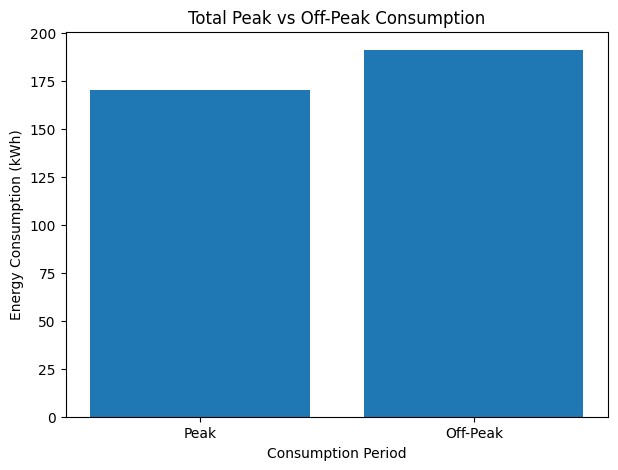

In [31]:
plt.figure(figsize=(7, 5))

plt.bar(["Peak", "Off-Peak"], [total_peak, total_off_peak])

plt.title("Total Peak vs Off-Peak Consumption")
plt.xlabel("Consumption Period")
plt.ylabel("Energy Consumption (kWh)")

plt.show()

Key Findings

- Total electricity consumption for the week was 361 kWh.
- The average daily electricity consumption was approximately 51.57 kWh.
- Saturday recorded the highest electricity consumption.
- Total off-peak consumption was higher than total peak consumption during the week.
- Approximately 46.71% of daily electricity consumption occurred during peak hours on average.
- 3 out of 7 days (42.86%) had electricity consumption above the weekly average.
- The analysis shows that electricity usage varied across the days of the week.

Conclusion

The electricity consumption analysis provided useful insights into weekly energy usage patterns. The results showed that consumption varied across the days, with Saturday recording the highest usage. Off-peak consumption was slightly higher than peak consumption over the week. Overall, Python, Pandas, NumPy, and Matplotlib were used to organize, analyze, and visualize the electricity consumption data effectively.